# Hands-On 2: Decision trees and estimated performance

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay
from mlcourse.labs import split_classification
from mlcourse.widgets import interactive_tree
from sklearn.metrics import roc_auc_score

## 1. Prepare a classification task

Load the reservations data. Select the numeric predictors and encode the target.

**Prediction:** Why exclude `booking_status` from the predictors?

The target contains the answer we want to estimate, so it must be separated from the inputs.

In [3]:
data = load_course_data('hotel')
features = [c for c in data if c.startswith('no_of_')] + ['required_car_parking_space', 'lead_time', 'repeated_guest', 'avg_price_per_room']
X = data[features]
y = data.booking_status.eq('Canceled').astype(int)
X_train, X_test, y_train, y_test = split_classification(X, y)
display(X.head())
display(pd.DataFrame({'train_count': y_train.value_counts(), 'test_count': y_test.value_counts()}))

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,no_of_previous_cancellations,...,no_of_special_requests,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room
0,2,0,1,2,0,...,0,0,224,0,65.000
1,2,0,2,3,0,...,1,0,5,0,106.680
2,1,0,2,1,0,...,0,0,1,0,60.000
3,2,0,0,2,0,...,0,0,211,0,100.000
4,2,0,1,1,0,...,0,0,48,0,94.500


,train_count,test_count
booking_status,,
0,17073,7317
1,8319,3566


**Observation:** Which information is available to the classifier?

The preview contains 11 numeric predictors, including lead time and counts of nights and requests. Class `1` denotes cancellation; the test partition contains 3,566 such observations.

**Explanation:** Explain the roles of predictors and target.

The tree learns relationships from labelled training observations. Evaluation asks whether those relationships predict targets for observations excluded from fitting.

## 2. Inspect a small tree

Fit `DecisionTreeClassifier(max_depth=3)`. Display its first two levels.

**Prediction:** What shape does a split on one feature create?

A single-feature threshold cuts along one coordinate axis.

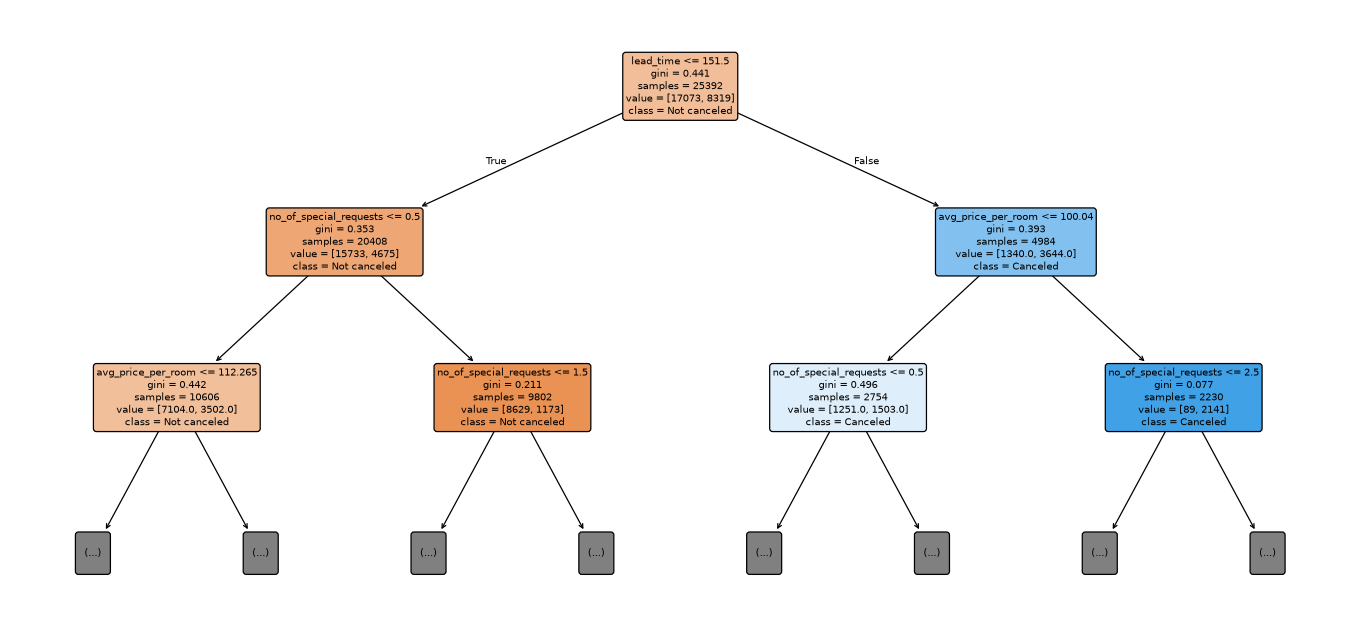

Train accuracy: 0.786
Test accuracy: 0.783


In [4]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(15, 7), layout='constrained')
plot_tree(tree, feature_names=features, class_names=['Not canceled', 'Canceled'],
          max_depth=2, filled=True, rounded=True, fontsize=8, ax=ax)
plt.show()
print(f'Train accuracy: {accuracy_score(y_train, tree.predict(X_train)):.3f}')
print(f'Test accuracy: {accuracy_score(y_test, tree.predict(X_test)):.3f}')

**Observation:** Trace one sequence of split conditions.

The root splits on `lead_time` at 151.500. Taking the left branch then tests `no_of_special_requests` at 0.500, forming a region constrained by both coordinates.

**Explanation:** How do the conditions define a region of feature space?

The conjunction of thresholds defines an axis-aligned region. A leaf assigns one class throughout that region.

## 3. Inspect classification errors

Display the confusion matrix and ROC curve for the same fitted tree.

**Prediction:** Can changing the probability threshold change predictions without fitting another tree?

Yes. The fitted leaf probabilities remain fixed while the threshold changes which leaves predict class `1`.

ROC AUC: 0.796


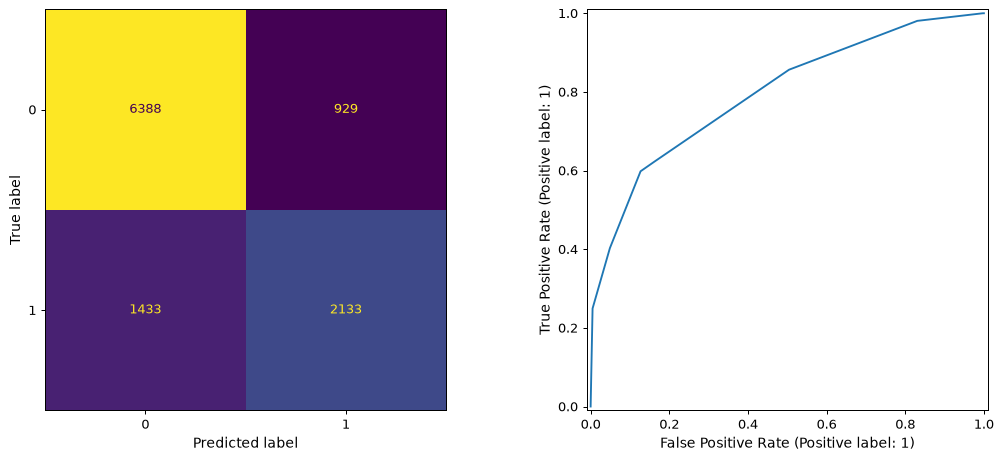

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test, ax=axes[0], colorbar=False)
RocCurveDisplay.from_estimator(tree, X_test, y_test, ax=axes[1])
axes[1].get_legend().remove()
print(f'ROC AUC: {roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1]):.3f}')
plt.show()

**Observation:** Which errors appear in the off-diagonal cells?

There are 929 false positives and 1,433 false negatives at the default rule. The ROC AUC is 0.796.

**Explanation:** Relate the ROC curve to changing the threshold.

A lower threshold usually labels more observations positive. The ROC curve summarises that trade-off across thresholds for this fixed fitted model.

## 4. Estimate variability

Compute five stratified cross-validation scores using the training partition.

**Prediction:** Will the five scores be identical?

The scores can differ because each fold changes the training observations and the held-out observations.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
fold_scores = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=0), X_train, y_train, cv=cv)
display(pd.DataFrame({'fold': np.arange(1, 6), 'accuracy': fold_scores}))
print(f'Mean accuracy: {fold_scores.mean():.3f}; standard deviation: {fold_scores.std(ddof=1):.3f}')

,fold,accuracy
0,1,0.783
1,2,0.789
2,3,0.782
3,4,0.786
4,5,0.791


Mean accuracy: 0.786; standard deviation: 0.004


**Observation:** Describe the spread of the scores.

Fold accuracies range from 0.782 to 0.791, with mean 0.786 and standard deviation 0.004. This configuration varies little across these five partitions.

**Explanation:** Why can a fixed configuration have different estimated performance across folds?

The fitted partitions can change with the training sample, and each held-out fold has different observations. Both effects contribute to variability.

## 5. Inspect sample size and capacity

Compare shallow and deeper trees at three training-set sizes.

**Prediction:** Which configuration should fit small training samples most closely?

The deeper tree has more capacity to fit small training samples.

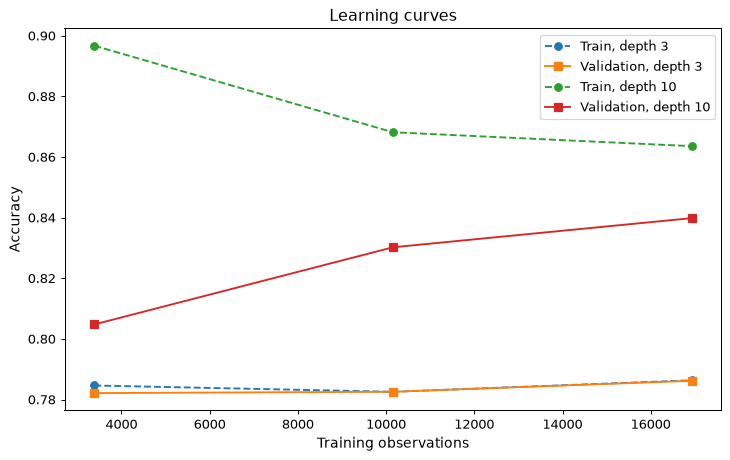

,max_depth,n_training,train_accuracy,validation_accuracy
0,3,3385,0.785,0.782
1,3,10156,0.783,0.783
2,3,16928,0.786,0.786
3,10,3385,0.897,0.805
4,10,10156,0.868,0.830
5,10,16928,0.864,0.840


In [7]:
rows = []
for depth in [3, 10]:
    sizes, train_scores, validation_scores = learning_curve(
        DecisionTreeClassifier(max_depth=depth, random_state=0), X_train, y_train,
        train_sizes=[.2, .6, 1.0], cv=3, shuffle=True, random_state=0)
    for size, train_score, validation_score in zip(sizes, train_scores.mean(axis=1), validation_scores.mean(axis=1)):
        rows.append({'max_depth': depth, 'n_training': size, 'train_accuracy': train_score, 'validation_accuracy': validation_score})
curve = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
for depth, group in curve.groupby('max_depth'):
    ax.plot(group.n_training, group.train_accuracy, '--o', label=f'Train, depth {depth}')
    ax.plot(group.n_training, group.validation_accuracy, '-s', label=f'Validation, depth {depth}')
ax.set(xlabel='Training observations', ylabel='Accuracy', title='Learning curves')
ax.legend()
plt.show()
display(curve)

**Observation:** Compare the train-validation gaps.

At the smallest training size, the depth-ten tree scores 0.897 on training data and 0.805 on validation data. At the largest size those scores are 0.864 and 0.840, so the gap narrows.

**Explanation:** Explain the gaps using model capacity and sample size.

A flexible tree can fit small regions supported by few examples. More observations can make those local decisions less sensitive to individual points.

## 6. Manipulate tree geometry

Use `ds2` to vary `max_depth` and `min_samples_leaf` in a two-dimensional feature space.

**Prediction:** How should increasing `min_samples_leaf` affect small regions?

Larger leaves require more supporting observations and should remove some small regions.

In [8]:
geometry = load_course_data('ds2')
a, b, c, d = split_classification(geometry[['X1', 'X2']], geometry.Class)
tree_lab = interactive_tree(a, b, c, d)
display(tree_lab.widget)

**Observation:** Record a setting that removes small regions.

At `max_depth=10`, increasing `min_samples_leaf` from `1` to `20` removes small rectangular regions. Test accuracy changes from 0.900 to 0.817 on this split.

**Explanation:** Explain why depth and leaf size both constrain capacity.

Depth limits the number of successive decisions. Leaf size limits how small a supported terminal region can become.